## Evaluation of distance data in relation with kNDVI and with the latent dimensions

In [15]:
csv_data = '48_outputs/LigniteData.csv'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from statsmodels.multivariate.manova import MANOVA
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

First, the data is to be loaded and filtered to use only distances between 1500 and 8000 meters.

In [16]:
# read CSV
df = pd.read_csv(csv_data)
# for site 48 this is rougly 68 million samples, which is too much for processing in a reasonable time

# for processing, we can sample a subset of the data to speed up processing
# df = df.sample(
#     n=1_000_000,
#     random_state=42
# )

# filter data to only include samples with distance to lignite between 1500m and 8000m
df = df[
    (df["DistanceToLignite"] > 1500) &
    (df["DistanceToLignite"] < 8000)
]

# print size of the filtered dataset
print(f"Filtered dataset size: {len(df)} samples")

Filtered dataset size: 67661558 samples


For simple qualitative evaluation, the relationship between distance and kNDVI is plotted. The data is binned to show the mean and 95% confidence interval of kNDVI for each bin.

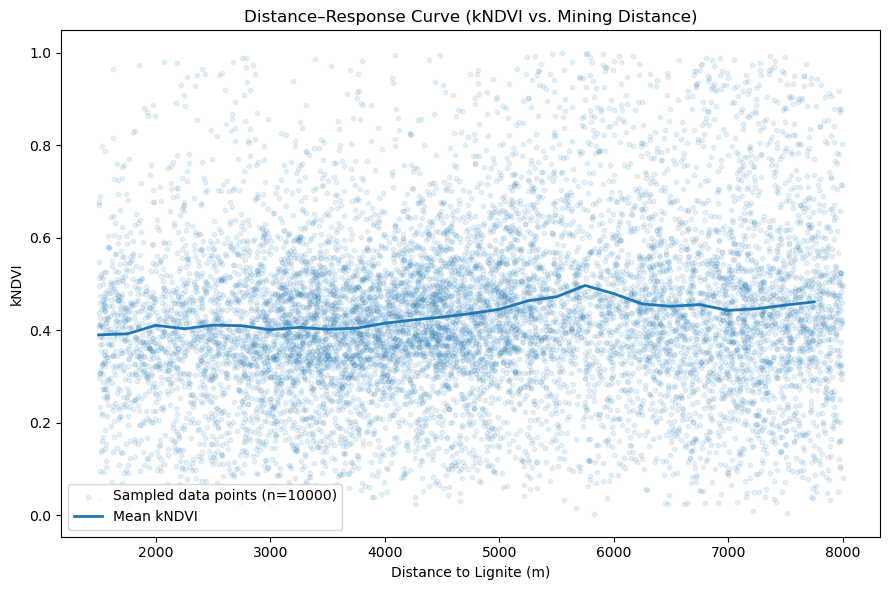

In [17]:
bin_size = 250  # meters

df_plot = df.copy()
df_plot["dist_bin"] = (df_plot["DistanceToLignite"] // bin_size) * bin_size

agg = df_plot.groupby("dist_bin")["kNDVI"].agg(
    mean="mean",
    std="std",
    count="count"
).reset_index()

# remove small bins with less then 1000 samples
agg = agg.where(agg["count"] > 1000).dropna()

agg["sem"] = agg["std"] / np.sqrt(agg["count"])
agg["ci_low"] = agg["mean"] - 1.96 * agg["sem"]
agg["ci_high"] = agg["mean"] + 1.96 * agg["sem"]

plt.figure(figsize=(9, 6))

#scatter plot of sampled data points
n_sample = min(10000, len(df_plot))
sample = df_plot.sample(n=n_sample, random_state=42)
plt.scatter(
    sample["DistanceToLignite"],
    sample["kNDVI"],
    alpha=0.1,
    s=10,
    label=f"Sampled data points (n={n_sample})"
)

# mean curve
plt.plot(
    agg["dist_bin"],
    agg["mean"],
    label="Mean kNDVI",
    linewidth=2
)

# confidence band
# plt.fill_between(
#     agg["dist_bin"],
#     agg["ci_low"],
#     agg["ci_high"],
#     alpha=0.3,
#     label="95% CI"
# )

plt.xlabel("Distance to Lignite (m)")
plt.ylabel("kNDVI")
plt.title("Distance–Response Curve (kNDVI vs. Mining Distance)")
plt.legend(loc="lower left")


plt.tight_layout()
plt.savefig("Lignite_Distance_Response_Curve_kNDVI_vs_Mining_Distance.png", dpi=300)
plt.show()

kNDVI is first used to evaluate the relationship with distance. A simple linear model is fitted to the data and the results are plotted. The model is evaluated using R-squared and p-value.

Intercept: 0.370713
Slope:     0.0000128154
R²:        0.015789


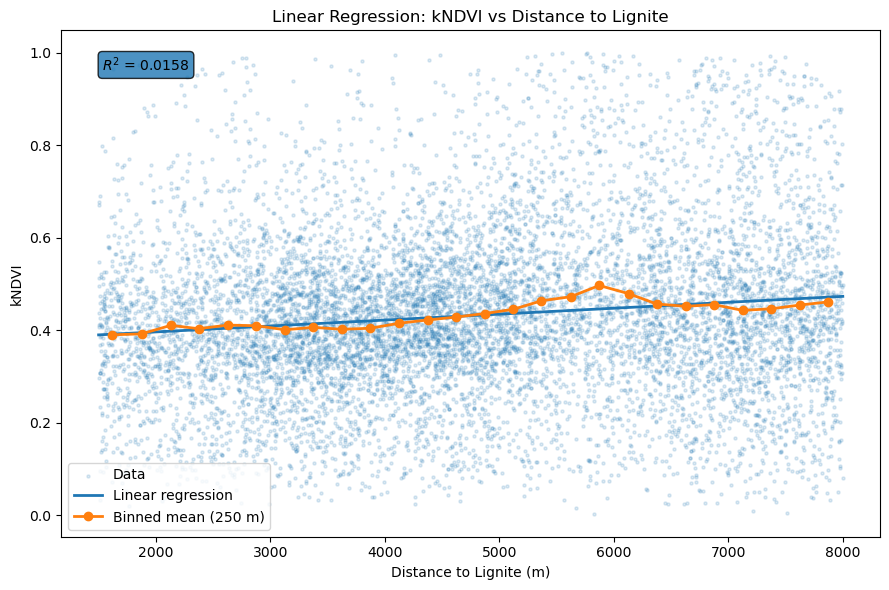

In [18]:
# ------------------------------------------------------------------
# Filter data
# ------------------------------------------------------------------

# Remove missing values and filter for the relevant columns
df_reg = df[["DistanceToLignite", "kNDVI"]].dropna()

# ------------------------------------------------------------------
# Linear regression with scikit-learn
# ------------------------------------------------------------------
x = df_reg[["DistanceToLignite"]]   # must be 2D for sklearn
y = df_reg["kNDVI"]

model = LinearRegression()
model.fit(x, y)

# Coefficients
intercept = model.intercept_
slope = model.coef_[0]
# R²
r2 = model.score(x, y)

print(f"Intercept: {intercept:.6f}")
print(f"Slope:     {slope:.10f}")
print(f"R²:        {r2:.6f}")

# ------------------------------------------------------------------
# Prediction line
# ------------------------------------------------------------------

x_pred = pd.DataFrame({
    "DistanceToLignite": [df_reg["DistanceToLignite"].min(), df_reg["DistanceToLignite"].max()]
})
y_pred = model.predict(x_pred)

bin_size = 250  # meters

df_reg["dist_bin"] = (df_reg["DistanceToLignite"] // bin_size) * bin_size

summary = (
    df_reg
    .groupby("dist_bin", observed=True)
    .agg(
        distance_mean=("DistanceToLignite", "mean"),
        kndvi_mean=("kNDVI", "mean"),
    )
    .reset_index()
)

# ------------------------------------------------------------------
# Plot
# ------------------------------------------------------------------
plt.figure(figsize=(9, 6))

n_sample = min(10000, len(df_reg))
sample = df_reg.sample(n=n_sample, random_state=42)

plt.scatter(
    sample["DistanceToLignite"],
    sample["kNDVI"],
    s=5,
    alpha=0.15,
    label="Data"
)

plt.plot(
    x_pred["DistanceToLignite"],
    y_pred,
    linewidth=2,
    label="Linear regression"
)

plt.plot(
    summary["distance_mean"],
    summary["kndvi_mean"],
    marker="o",
    linewidth=2,
    label=f"Binned mean ({bin_size} m)"
)

plt.xlabel("Distance to Lignite (m)")
plt.ylabel("kNDVI")
plt.title("Linear Regression: kNDVI vs Distance to Lignite")

plt.text(
    0.05,
    0.95,
    f"$R^2$ = {r2:.4f}",
    transform=plt.gca().transAxes,
    va="top",
    bbox=dict(boxstyle="round", alpha=0.8)
)
plt.legend(loc="lower left")

plt.tight_layout()
plt.savefig("Lignite_Linear_Regression_kNDVI_vs_Mining_Distance.png", dpi=300)
plt.show()

A MANOVA is performed to evaluate the relationship between distance and the latent dimensions. For this, each latent dimension is regressed against distance and the results are then checked, if the vector of regression coefficients is significantly different from zero. The results are evaluated using Pillai's trace. It is like R^2, but for multivariate regression.

In [19]:
# ------------------------------------------------------------------
# Filter data
# ------------------------------------------------------------------
features = [f"feature_{i}" for i in range(6)]

df_manova = df[
    features + ["DistanceToLignite"]
].copy()

print("Samples used for MANOVA:", len(df_manova))

# ------------------------------------------------------------------
# MANOVA: Does distance affect the transformer latent vegetation space?
# ------------------------------------------------------------------

# MANOVA model
formula = (
    "feature_0 + feature_1 + feature_2 + "
    "feature_3 + feature_4 + feature_5 "
    "~ DistanceToLignite"
)

manova = MANOVA.from_formula(
    formula,
    data=df_manova
)

result = manova.mv_test()

print(result)


Samples used for MANOVA: 67661558
                         Multivariate linear model
                                                                           
---------------------------------------------------------------------------
       Intercept         Value  Num DF     Den DF        F Value     Pr > F
---------------------------------------------------------------------------
          Wilks' lambda  0.0109 6.0000 67661551.0000 1019877554.7849 0.0000
         Pillai's trace  0.9891 6.0000 67661551.0000 1019877554.7849 0.0000
 Hotelling-Lawley trace 90.4393 6.0000 67661551.0067 1019877554.7849 0.0000
    Roy's greatest root 90.4393 6.0000 67661551.0000 1019877554.7849 0.0000
---------------------------------------------------------------------------
                                                                           
----------------------------------------------------------------------------
    DistanceToLignite     Value   Num DF      Den DF       F Value    Pr > F
-

Pillai's trace is 0.0310. This value shows that there is effect of distance on the latent dimensions.

Now, a PCA is performed on the latent dimensions to find the combination of latent dimensions that is most strongly related to distance.

In [20]:
# ------------------------------------------------------------------
# Settings
# ------------------------------------------------------------------
features = [f"feature_{i}" for i in range(6)]

# ------------------------------------------------------------------
# Prepare data
# ------------------------------------------------------------------

df_pca = df[features + ["DistanceToLignite"]]

# ------------------------------------------------------------------
# Standardize latent features and compute PCA
# ------------------------------------------------------------------
scaler = StandardScaler()

X_scaled = scaler.fit_transform(df_pca[features])

pca = PCA()
pcs = pca.fit_transform(X_scaled)

pc_names = [f"PC{i+1}" for i in range(len(features))]

df_pc = pd.DataFrame(
    pcs,
    columns=pc_names,
    index=df_pca.index
)

df_pc["DistanceToLignite"] = df_pca["DistanceToLignite"]

# ------------------------------------------------------------------
# Print explained variance
# ------------------------------------------------------------------
print("\nExplained variance ratio:")

for pc, var in zip(pc_names, pca.explained_variance_ratio_):
    print(f"{pc}: {var:.4f}")

print("\nCumulative explained variance:")

for pc, var in zip(pc_names, np.cumsum(pca.explained_variance_ratio_)):
    print(f"{pc}: {var:.4f}")



Explained variance ratio:
PC1: 0.3204
PC2: 0.2169
PC3: 0.2099
PC4: 0.1205
PC5: 0.0962
PC6: 0.0361

Cumulative explained variance:
PC1: 0.3204
PC2: 0.5374
PC3: 0.7472
PC4: 0.8677
PC5: 0.9639
PC6: 1.0000


Now the PCs are evaluated in relation to distance. For this purpose, a linear regression is performed for each PC against distance. The results are evaluated using R-squared.

In [21]:
# ------------------------------------------------------------------
# Settings
# ------------------------------------------------------------------
features = [f"feature_{i}" for i in range(6)]
pc_names = [f"PC{i+1}" for i in range(len(features))]

# ------------------------------------------------------------------
# Regress each PC against distance
# This answers: which latent directions change with distance?
# ------------------------------------------------------------------
print("\nRegression of PCs against distance:")

for pc in pc_names:
    x_reg = df_pc[["DistanceToLignite"]]
    y_reg = df_pc[pc]

    model = LinearRegression()
    model.fit(x_reg, y_reg)

    print(
        f"{pc:4s} "
        f"R² = {model.score(x_reg, y_reg):.4f} "
        f"slope = {model.coef_[0]: .4e} "
    )


Regression of PCs against distance:
PC1  R² = 0.0002 slope = -1.1984e-05 
PC2  R² = 0.0075 slope =  5.6165e-05 
PC3  R² = 0.0130 slope =  7.2923e-05 
PC4  R² = 0.0071 slope = -4.0726e-05 
PC5  R² = 0.0019 slope = -1.8840e-05 
PC6  R² = 0.0009 slope = -8.1078e-06 


This shows that PCA2, PCA3 and PCA4 are the most important components for distance correlation. These are now used to fit a linear model to the data.

In [22]:
distance_pcs = ["PC2", "PC3", "PC4"]

# ------------------------------------------------------------------
# Build a latent vegetation distance index
# ------------------------------------------------------------------
# This creates the linear combination of PC2, PC3, PC4 that is most
# associated with distance.
#
# This is a hyperplane in the latent vegetation space that is most
# correlated with distance. We will call this the
# "latent distance index". The predicted value is distance-like, but
# here we use it only as an index of distance-related vegetation
# state.
# ------------------------------------------------------------------
x_index = df_pc[distance_pcs]
y_distance = df_pc["DistanceToLignite"]

model = LinearRegression()
model.fit(x_index, y_distance)

df_pc["latent_distance_index"] = model.predict(x_index)

print("\nLatent distance index model:")
print(f"PCs used: {distance_pcs}")
print(f"Intercept: {model.intercept_:.6f}")
print(f"Slope PC2: {model.coef_[0]:.10f}")
print(f"Slope PC3: {model.coef_[1]:.10f}")
print(f"Slope PC4: {model.coef_[2]:.10f}")
print(f"R² = {model.score(x_index, y_distance):.4f}")


Latent distance index model:
PCs used: ['PC2', 'PC3', 'PC4']
Intercept: 4771.076445
Slope PC2: 132.8128707013
Slope PC3: 178.2018319232
Slope PC4: -173.3893996373
R² = 0.0275


In [23]:
# ------------------------------------------------------------------
# Linear Regression of latent index against true distance
# ------------------------------------------------------------------
x_pca_reg = df_pc[["DistanceToLignite"]]
y_pca_reg = df_pc["latent_distance_index"]

# distanz -> proj(s1*PC2 + s2*PC3 + s3*PC4)

model = LinearRegression()
model.fit(x_pca_reg, y_pca_reg)

x_pred = pd.DataFrame({
    "DistanceToLignite": [df_pc["DistanceToLignite"].min(), df_pc["DistanceToLignite"].max()]
})

y_pred = model.predict(x_pred)

r2_trend = model.score(x_pca_reg, y_pca_reg)
slope = model.coef_[0]
intercept = model.intercept_

print("\nLinear regression of latent distance index against true distance:")
print(f"Intercept: {intercept:.6f}")
print(f"Slope: {slope:.10f}")
print(f"R² = {r2_trend:.4f}")



Linear regression of latent distance index against true distance:
Intercept: 4639.795238
Slope: 0.0275160561
R² = 0.0275


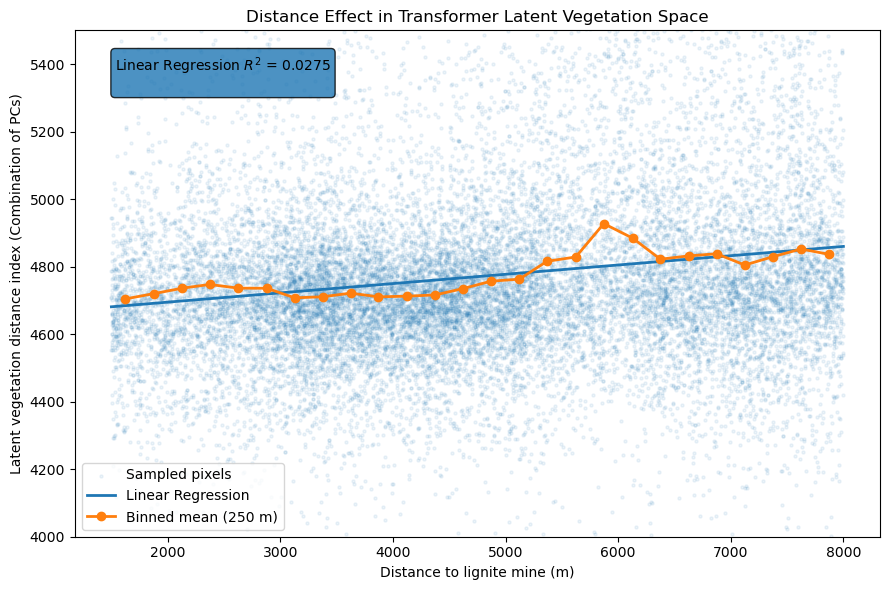

In [24]:
# ------------------------------------------------------------------
# Binned means for clear visual effect
# ------------------------------------------------------------------
bin_size = 250  # meters

df_pc["dist_bin"] = (df_pc["DistanceToLignite"] // bin_size) * bin_size

summary = (
    df_pc
    .groupby("dist_bin", observed=True)
    .agg(
        distance_mean=("DistanceToLignite", "mean"),
        index_mean=("latent_distance_index", "mean"),
    )
    .reset_index()
)

# ------------------------------------------------------------------
# Plot
# ------------------------------------------------------------------
plt.figure(figsize=(9, 6))

# Optional raw sample for background cloud
n_sample = min(20000, len(df_pc))

sample = df_pc.sample(
    n=n_sample,
    random_state=42
)

plt.scatter(
    sample["DistanceToLignite"],
    sample["latent_distance_index"],
    s=5,
    alpha=0.08,
    label="Sampled pixels"
)

# Regression line
plt.plot(
    x_pred,
    y_pred,
    linewidth=2,
    label="Linear Regression"
)

# Binned means
plt.plot(
    summary["distance_mean"],
    summary["index_mean"],
    marker="o",
    linewidth=2,
    label=f"Binned mean ({bin_size} m)"
)

plt.xlabel("Distance to lignite mine (m)")
plt.ylabel("Latent vegetation distance index (Combination of PCs)")
plt.title("Distance Effect in Transformer Latent Vegetation Space")

plt.text(
    0.05,
    0.95,
    (
        f"Linear Regression $R^2$ = {r2_trend:.4f}\n"
    ),
    transform=plt.gca().transAxes,
    va="top",
    bbox=dict(boxstyle="round", alpha=0.8)
)

# limit y axis between 4000 and 5500
plt.ylim(4000, 5500)
plt.legend(loc="lower left")

plt.tight_layout()
plt.savefig("Lignite_Distance_Effect_in_Transformer_Latent_Vegetation_Space.png", dpi=300)
plt.show()